<a href="https://colab.research.google.com/github/keyonai/OCR-practice/blob/main/KeyonaiWilliams_Compare_3_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
OCR Extracted Text:

Certificate of Quality

 

roaat: AKTA™ ready Gradient Flow Section With inlets
Met emer: L722 Prothact Aetcte Wambo PP 188612
(Date ot Mametnctare: 2OPI002%

Dopration Date: 20280128

Protect Deseroton: Hg) Plow Gradient C Modiied AKTA™ veaty

 

Product Release Criteria

Re Nereey cart that the cote peoduct Nat Dee mart actored 12 cet ts soeeHcrtoes ane hone Deen vented 12
(Peet ereteterenet CRs! to Qutty eres ond the Row bt has Deer forma setease fr Bevery

Description Umies
etociowe

nome eg RY C> 1S me
Corene etaren,

7 o- we Ky

 

Regulatory Conformance:
Bo-aateny

1B peters mater ie coma wth he proces ad caret Ath tee Daten Pharma ope (SP) BR: Rage a
(nesciety Vest Claus i and a Se fren aetna eorwend Hgreenes Or Wy Compare A HNAA/E HDL

C

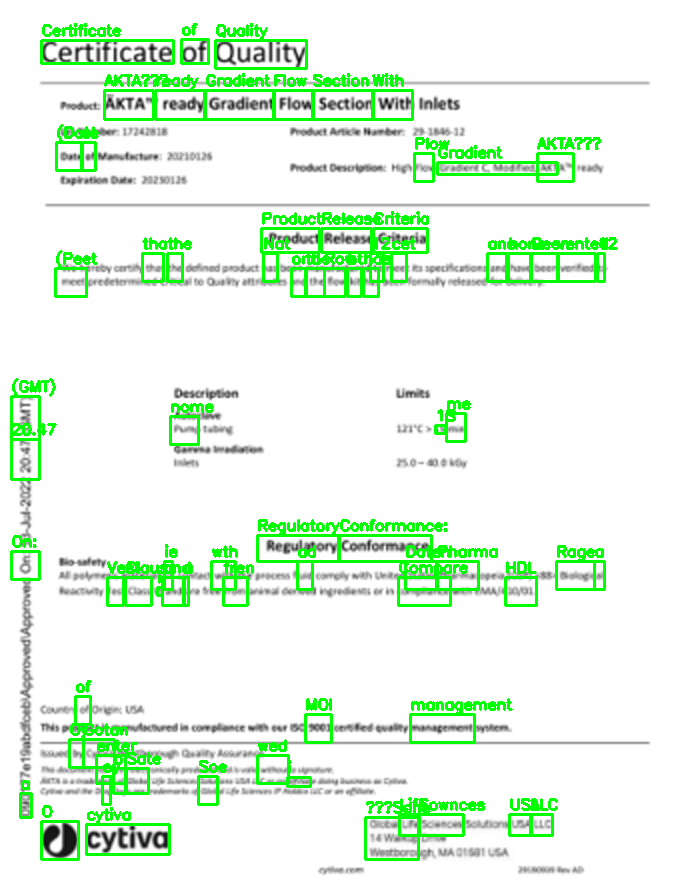

In [ ]:
!apt install -y tesseract-ocr  # Install Tesseract OCR
!pip install pymupdf pytesseract opencv-python pillow numpy  # Install required Python libraries
import cv2
import pytesseract
import fitz  # PyMuPDF
import numpy as np
from PIL import Image

# Load the scanned PDF
pdf_path = "pharmaceutical-sdf-page3-certificate-quality.pdf"  # Update this path if needed
doc = fitz.open(pdf_path)
# Convert the first page to an image
pix = doc[0].get_pixmap() # Access the first page (doc[0]) before calling get_pixmap()
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
# Convert the image to grayscale
img = np.array(img)  # Convert PIL image to NumPy array
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# Apply adaptive thresholding to enhance contrast
#gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
# Apply Bilateral Filtering for noise reduction
#gray = cv2.bilateralFilter(gray, 9, 75, 75)
# Resize image for better OCR accuracy
scale_percent = 200  # Increase image size by 200%
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)
# Run OCR on the preprocessed image
custom_config = r'--oem 3 -l eng'
ocr_text = pytesseract.image_to_string(gray, config=custom_config)
# Print extracted text
print("OCR Extracted Text:\n")
print(ocr_text)

#optional bounding boxes
# Extract bounding box data from OCR
ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

# Convert image to OpenCV BGR format
img_bgr = cv2.cvtColor(gray, cv2.COLOR_RGB2BGR)

# Get OpenCV image height for correct y-coordinate transformation
page_height = gray.shape[0]

# Define confidence threshold (ignore low-confidence words)
confidence_threshold = 40

# Loop through Extracted OCR Words & Draw Bounding Boxes
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    x, y, w, h = ocr_data["left"][i], ocr_data["top"][i], ocr_data["width"][i], ocr_data["height"][i]
    conf = int(ocr_data["conf"][i])  # Convert confidence to int

    # Ignore empty words & low-confidence OCR text
    if not word or conf < confidence_threshold:
        continue

    # Draw bounding box
    cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_bgr, word, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Convert Back to RGB & Display the Image
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
display(Image.fromarray(img_rgb))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
All packages installed!
Libraries imported successfully!
Upload your PDF file:


Saving pharmaceutical-sdf-page3-certificate-quality.pdf to pharmaceutical-sdf-page3-certificate-quality (14).pdf
Uploaded: /content/pharmaceutical-sdf-page3-certificate-quality (14).pdf


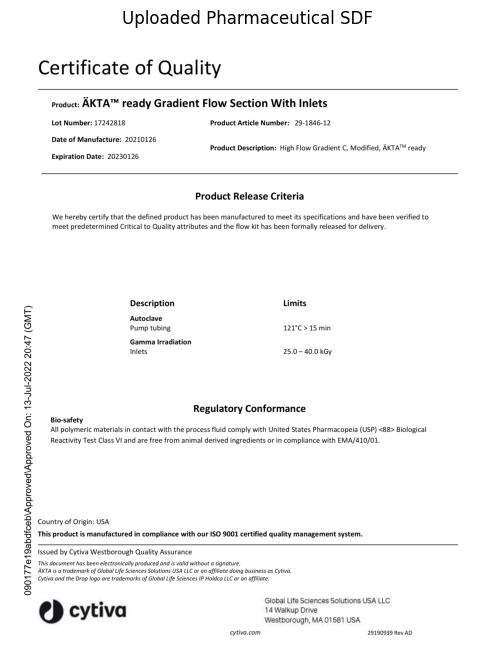

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Initializing PaddleOCR...


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Running OCR...


/tmp/ipykernel_45485/1576878973.py:48: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(image_path)


NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)


In [ ]:
# Install PaddleOCR and its deep learning framework
!pip install paddleocr
!pip install paddlepaddle

# Install PDF conversion tools
!pip install pdf2image
!apt-get install poppler-utils -y

print("All packages installed!")
from paddleocr import PaddleOCR
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab import files

print("Libraries imported successfully!")

# Upload your pharmaceutical SDF
print("Upload your PDF file:")
uploaded = files.upload()
# Get the filename
pdf_path = f"/content/{list(uploaded.keys())[0]}"
print(f"Uploaded: {pdf_path}")

# Convert PDF to image using pdf2image
images = convert_from_path(pdf_path, dpi=300)
image = images[0]  # Use first page

# Save as PNG for OCR
image_path = '/content/pharmaceutical_sdf.png'
image.save(image_path, 'PNG')
# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title('Uploaded Pharmaceutical SDF')
plt.axis('off')
plt.show()
# Initialize PaddleOCR (downloads model files on first run)
print("Initializing PaddleOCR...")

# Reverting to the suggested parameter for PaddleOCR initialization to address the DeprecationWarning
ocr = PaddleOCR(use_textline_orientation=True, lang='en')

# Run OCR on the image
print("Running OCR...")
result = ocr.ocr(image_path)

print(f"Found {len(result[0])} text regions!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 106.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 160.3 kB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


Saving pharmaceutical-sdf-page3-certificate-quality.pdf to pharmaceutical-sdf-page3-certificate-quality (15).pdf


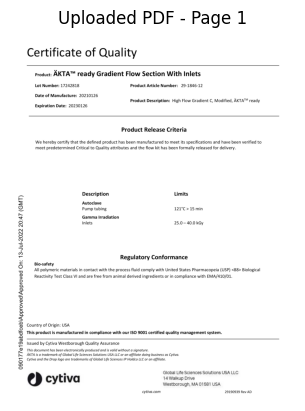

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


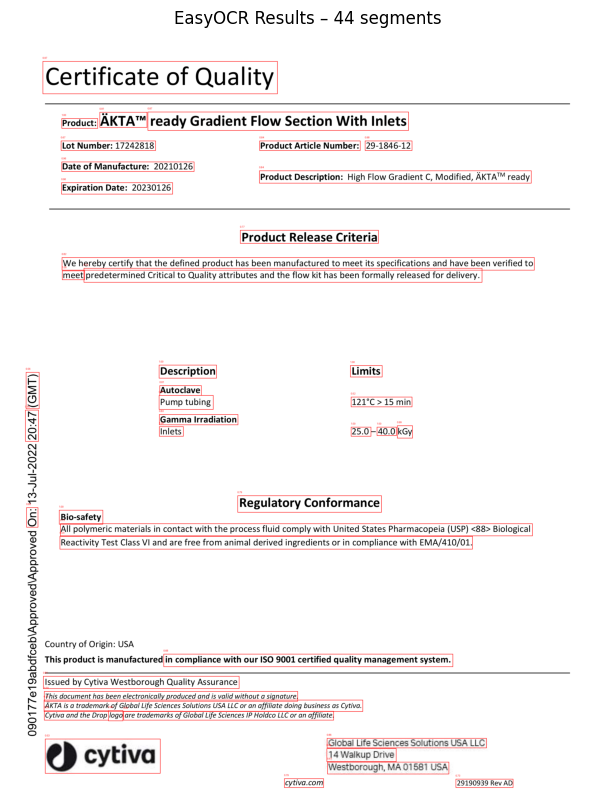


📝 Extracted Text (44 segments):
 1. Certificate of Quality
 2. Product:
 3. AKTATm
 4. ready Gradient Flow Section With Inlets
 5. Lot Number: 17242818
 6. Product Article Number:
 7. 29-1846-12
 8. Date of Manufacture: 20210126
 9. Product Description: High Flow Gradient C, Modified, AKTATM ready
10. Expiration Date: 20230126
11. Product Release Criteria
12. We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
13. meet
14. predetermined Critical to Quality attributes and the flow kit has been formally released for delivery:
15. Description
16. Limits
17. 8
18. Autoclave
19. Pump tubing
20. 1218C > 15 min
21. Gamma Irradiation
22. 8
23. Inlets
24. 25.0
25. 40.0
26. Regulatory Conformance
27. 8
28. Bio-safety
29. All polymeric materials in contact with the process fluid comply with United States Pharmacopeia (USP) <88> Biological
30. Reactivity Test Class VI and are free from animal derived ingredients or in compliance wi

In [ ]:
!pip install easyocr
!pip install pdf2image
!apt-get install poppler-utils -y
from google.colab import files
from pdf2image import convert_from_path
from PIL import Image
import matplotlib.pyplot as plt

# Upload your file
uploaded = files.upload()
pdf_path = f"/content/{list(uploaded.keys())[0]}"

# Convert first page to image
images = convert_from_path(pdf_path, dpi=300)
image = images[0]
image_path = '/content/page.png'
image.save(image_path)

# Show preview
plt.imshow(image)
plt.axis('off')
plt.title("Uploaded PDF - Page 1")
plt.show()
import easyocr
from PIL import ImageDraw

# Initialize reader
reader = easyocr.Reader(['en'])

# Run OCR
result = reader.readtext(image_path)

# Visualize
img_copy = image.copy()
draw = ImageDraw.Draw(img_copy)
extracted_text = []

for (bbox, text, confidence) in result:
    if confidence > 0.5:
        # Bounding box
        top_left = tuple(map(int, bbox[0]))
        bottom_right = tuple(map(int, bbox[2]))
        draw.rectangle([top_left, bottom_right], outline='red', width=2)

        # Confidence score
        draw.text((top_left[0], top_left[1] - 20), f"{confidence:.2f}", fill='red')

        extracted_text.append(text)

plt.figure(figsize=(15, 10))
plt.imshow(img_copy)
plt.axis('off')
plt.title(f"EasyOCR Results – {len(extracted_text)} segments")
plt.show()
print(f"\n📝 Extracted Text ({len(extracted_text)} segments):")
for i, text in enumerate(extracted_text, 1):
    print(f"{i:2d}. {text}")